# Chapter 3 — Unsupervised Learning Warm-up

This notebook accompanies **Chapter 3** of *Inference in Statistical Modelling and Machine Learning*.

## Key ideas

In Chapter 2 we predicted a response variable from features. Here there is no response variable: we are given a set of two-dimensional points and asked to build a **density function** — a smooth surface whose height at each location reflects how densely points are distributed there. This is an **unsupervised** learning problem.

Three ideas from Chapter 2 reappear in this new setting:

- The **log-product score** provides a quantitative measure of how well a density fits a dataset.
- A density with too many free parameters **overfits** — it memorises the data rather than capturing the underlying pattern; one with too few **underfits**.
- **Cross-validation** finds a sweet spot between these extremes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

rng = np.random.default_rng(42)

In [ ]:
try:
    import google.colab
    DATA_PATH = "https://inferencebook.github.io/data/"
except ImportError:
    DATA_PATH = "../data/"


---
## 1 · The treasure-hunt problem

> **Book link — §3.1.**  Hoards of treasure were buried at secret locations. Bookworms have destroyed most of the records, leaving 90 readable location slips. The task: use dataset $D$ to build a **hoard score function** $f(x, y)$ — a density over the plane whose value at $(x, y)$ is proportional to the estimated chance of finding a new hoard when digging there.

Notice what is *not* happening here: we are not predicting $y$ from $x$. Both coordinates are on an equal footing; we care about the joint two-dimensional pattern.

Dataset D: 90 points
x range: [-1.99, 2.39]
y range: [-0.41, 1.93]


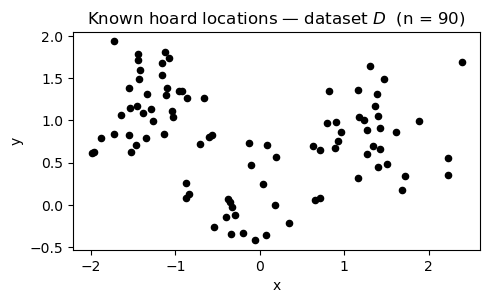

In [2]:
data = pd.read_csv(DATA_PATH + 'treasure.csv')
X    = data[['x', 'y']].values          # shape (90, 2)

print(f'Dataset D: {len(X)} points')
print(f'x range: [{X[:, 0].min():.2f}, {X[:, 0].max():.2f}]')
print(f'y range: [{X[:, 1].min():.2f}, {X[:, 1].max():.2f}]')

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[:, 0], X[:, 1], color='k', s=20, zorder=3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Known hoard locations — dataset $D$  (n = 90)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

Three rough clusters are visible: one top-left, one top-right, and one lower-middle. Our task is to build a density that captures this structure — and to decide, rigorously, how many clusters to use.

---
## 2 · A one-dimensional warm-up

> **Book link — §3.2.**  Before tackling two dimensions, we work through a simpler case. Suppose we have a cluster of points along a line and want to describe their distribution with a smooth density.

**Two candidates.** A **histogram** divides the line into equal-width bins and sets each bar's height so the total area is one. Alternatively we can fit a **Gaussian blob**

$$f(x;\, \mu, \sigma) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right),$$

controlled by a centre $\mu$ and a width $\sigma$.

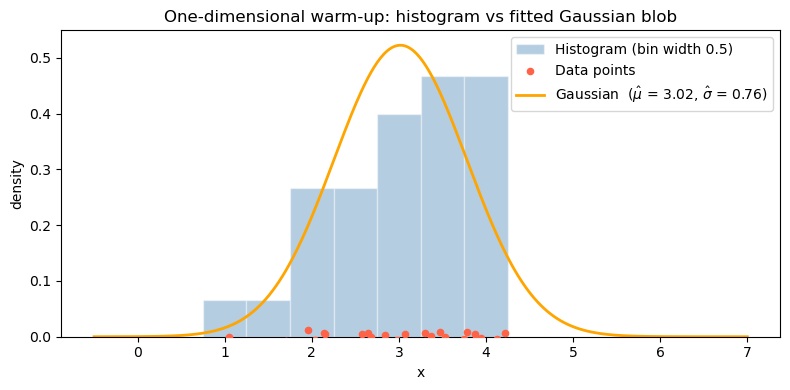

In [3]:
# Synthetic 1D cluster — 30 points near x = 3
x_1d   = rng.normal(loc=3.0, scale=1.0, size=30)
x_grid = np.linspace(-0.5, 7.0, 400)

mu_hat    = x_1d.mean()
sigma_hat = x_1d.std()       # divides by n — matches the score-maximising value (see below)

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(x_1d, bins=np.arange(-0.25, 6.75, 0.5), density=True,
        color='steelblue', alpha=0.4, edgecolor='white', label='Histogram (bin width 0.5)')

jitter = rng.uniform(-0.012, 0.012, size=len(x_1d))
ax.scatter(x_1d, jitter, color='tomato', s=20, zorder=4, label='Data points')

ax.plot(x_grid, norm.pdf(x_grid, mu_hat, sigma_hat),
        'orange', linewidth=2,
        label=f'Gaussian  ($\\hat{{\\mu}}$ = {mu_hat:.2f}, $\\hat{{\\sigma}}$ = {sigma_hat:.2f})')

ax.set_xlabel('x')
ax.set_ylabel('density')
ax.set_title('One-dimensional warm-up: histogram vs fitted Gaussian blob')
ax.set_ylim(bottom=0)
ax.legend()
plt.tight_layout()
plt.show()

**Choosing $\mu$ and $\sigma$.**  We want the density to be large where the data are. A natural first idea: maximise the *sum* of density values at the datapoints,

$$L_\text{sum}(\boldsymbol\theta) = \sum_{i=1}^n f(x_i;\, \mu, \sigma).$$

This leads to disaster.

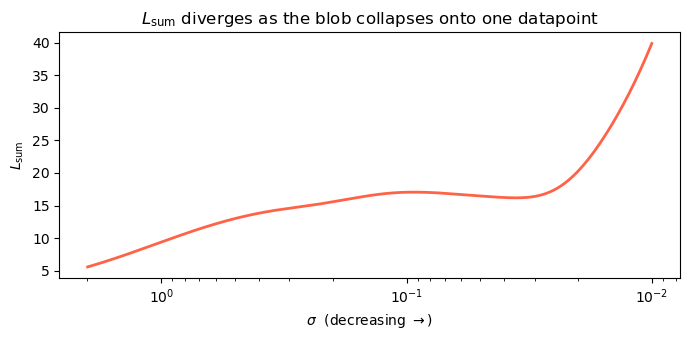

In [4]:
# Fix mu at the first datapoint and shrink sigma: L_sum explodes
sigmas = np.logspace(-2, 0.3, 300)
l_sum  = [np.sum(norm.pdf(x_1d, x_1d[0], s)) for s in sigmas]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(sigmas, l_sum, 'tomato', linewidth=2)
ax.invert_xaxis()
ax.set_xscale('log')
ax.set_xlabel('$\\sigma$  (decreasing $\\rightarrow$)')
ax.set_ylabel('$L_\\mathrm{sum}$')
ax.set_title('$L_\\mathrm{sum}$ diverges as the blob collapses onto one datapoint')
plt.tight_layout()
plt.show()

As $\sigma \to 0$ with the centre fixed on any datapoint, that datapoint contributes an arbitrarily large term while the cost of abandoning the others is ignored. The *product* of density values avoids this — collapsing the blob onto one point drives the densities at all other points to zero, which pulls the whole product down.

Working with the **logarithm** of the product — which turns products into sums and avoids numerical underflow — gives the **log-product score**:

$$\ell(\boldsymbol\theta) = \sum_{i=1}^n \log f(x_i;\, \mu, \sigma)
= -\frac{1}{2\sigma^2}\sum_{i=1}^n (x_i - \mu)^2 - n\log\sigma - \frac{n}{2}\log(2\pi).$$

Setting $\partial\ell/\partial\mu = 0$ and $\partial\ell/\partial\sigma = 0$ gives the best-fitting parameters: the **sample mean** and the **mean squared deviation from the sample mean** (Exercise 3.4 in the book). We can verify this numerically.

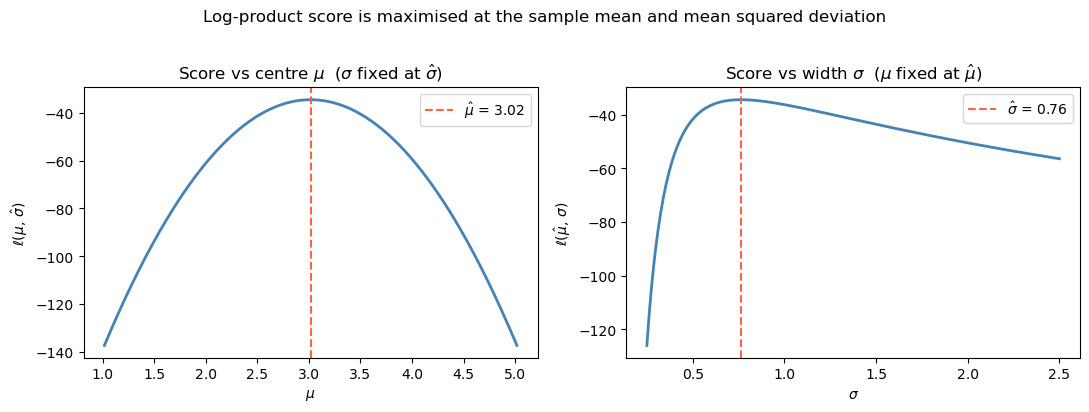

Best-fitting parameters:  mu_hat = 3.017,  sigma_hat = 0.764
Log-product score at best-fitting params: -34.480


In [5]:
# Log-product score as a function of mu (left) and sigma (right),
# with the other parameter held at its best-fitting value.
mu_range    = np.linspace(mu_hat - 2.0, mu_hat + 2.0, 300)
sigma_range = np.linspace(0.25, 2.5, 300)

scores_mu    = [np.sum(norm.logpdf(x_1d, m, sigma_hat)) for m in mu_range]
scores_sigma = [np.sum(norm.logpdf(x_1d, mu_hat, s))   for s in sigma_range]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(mu_range, scores_mu, 'steelblue', linewidth=2)
axes[0].axvline(mu_hat, color='tomato', linestyle='--',
                label=f'$\\hat{{\\mu}}$ = {mu_hat:.2f}')
axes[0].set_xlabel('$\\mu$')
axes[0].set_ylabel('$\\ell(\\mu,\\, \\hat{\\sigma})$')
axes[0].set_title('Score vs centre $\\mu$  ($\\sigma$ fixed at $\\hat{\\sigma}$)')
axes[0].legend()

axes[1].plot(sigma_range, scores_sigma, 'steelblue', linewidth=2)
axes[1].axvline(sigma_hat, color='tomato', linestyle='--',
                label=f'$\\hat{{\\sigma}}$ = {sigma_hat:.2f}')
axes[1].set_xlabel('$\\sigma$')
axes[1].set_ylabel('$\\ell(\\hat{\\mu},\\, \\sigma)$')
axes[1].set_title('Score vs width $\\sigma$  ($\\mu$ fixed at $\\hat{\\mu}$)')
axes[1].legend()

plt.suptitle('Log-product score is maximised at the sample mean and mean squared deviation',
             y=1.02)
plt.tight_layout()
plt.show()

print(f'Best-fitting parameters:  mu_hat = {mu_hat:.3f},  sigma_hat = {sigma_hat:.3f}')
print(f'Log-product score at best-fitting params: {np.sum(norm.logpdf(x_1d, mu_hat, sigma_hat)):.3f}')

---
## 3 · A single Gaussian blob in two dimensions

> **Book link — §3.3 (opening).**  Back to the treasure map. The two-dimensional analogue of our Gaussian blob is a **circularly-symmetric density** centred at $\boldsymbol\mu = (\mu_x, \mu_y)$ with width $\sigma$:

$$f(\boldsymbol{x};\, \boldsymbol\mu, \sigma) = \frac{1}{2\pi\sigma^2} \exp\!\left(-\frac{\|\boldsymbol{x} - \boldsymbol\mu\|^2}{2\sigma^2}\right).$$

The log-product score is maximised by the sample mean vector and by $\hat{\sigma}^2 = \frac{1}{2n}\sum_i \|\boldsymbol{x}_i - \hat{\boldsymbol\mu}\|^2$.

Best-fitting centre: (-0.104, 0.798)
Best-fitting width:  sigma = 0.945


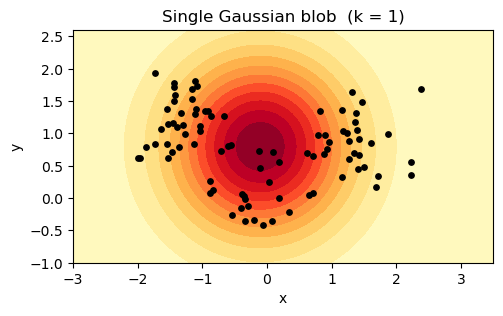

In [6]:
# Best-fitting single blob (k = 1)
gm1     = GaussianMixture(n_components=1, covariance_type='spherical', random_state=42)
gm1.fit(X)
mu_fit  = gm1.means_[0]
sig_fit = np.sqrt(gm1.covariances_[0])
print(f'Best-fitting centre: ({mu_fit[0]:.3f}, {mu_fit[1]:.3f})')
print(f'Best-fitting width:  sigma = {sig_fit:.3f}')

# Heat map grid (reused throughout the notebook)
xx      = np.linspace(-3.0, 3.5, 250)
yy      = np.linspace(-1.0, 2.6, 250)
XX, YY  = np.meshgrid(xx, yy)
XY_grid = np.column_stack([XX.ravel(), YY.ravel()])

Z1 = np.exp(gm1.score_samples(XY_grid)).reshape(XX.shape)

fig, ax = plt.subplots(figsize=(5, 5))
ax.contourf(XX, YY, Z1, levels=15, cmap='YlOrRd')
ax.scatter(X[:, 0], X[:, 1], color='k', s=15, zorder=4)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Single Gaussian blob  (k = 1)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

A single blob spreads the density across the whole dataset. It cannot capture the three-cluster structure visible in the scatter plot.

---
## 4 · Gaussian mixture models

> **Book link — §3.3.**  We replace the single blob with a **weighted sum of $k$ blobs** — a *Gaussian mixture*:

$$f(\boldsymbol{x};\, \boldsymbol\theta_k) = \sum_{i=1}^k \frac{w_i}{2\pi\sigma_i^2} \exp\!\left(-\frac{\|\boldsymbol{x} - \boldsymbol\mu_i\|^2}{2\sigma_i^2}\right),$$

where the weights satisfy $w_1 + \cdots + w_k = 1$, $w_i \geq 0$.  The parameter vector $\boldsymbol\theta_k$ has $5k - 1$ components: $k$ centres (2 coordinates each), $k$ widths, and $k - 1$ independent weights.

Finding the best-fitting parameters now requires **numerical optimisation**. A standard algorithm — expectation-maximisation (EM), initialised by K-means — handles this; we use `sklearn`'s `GaussianMixture` under the hood.

> **The collapse warning.**  The log-product score can be made arbitrarily large by shrinking one blob onto a single datapoint while the rest cover the others. To prevent this, we enforce a minimum blob width via the `reg_covar` parameter.

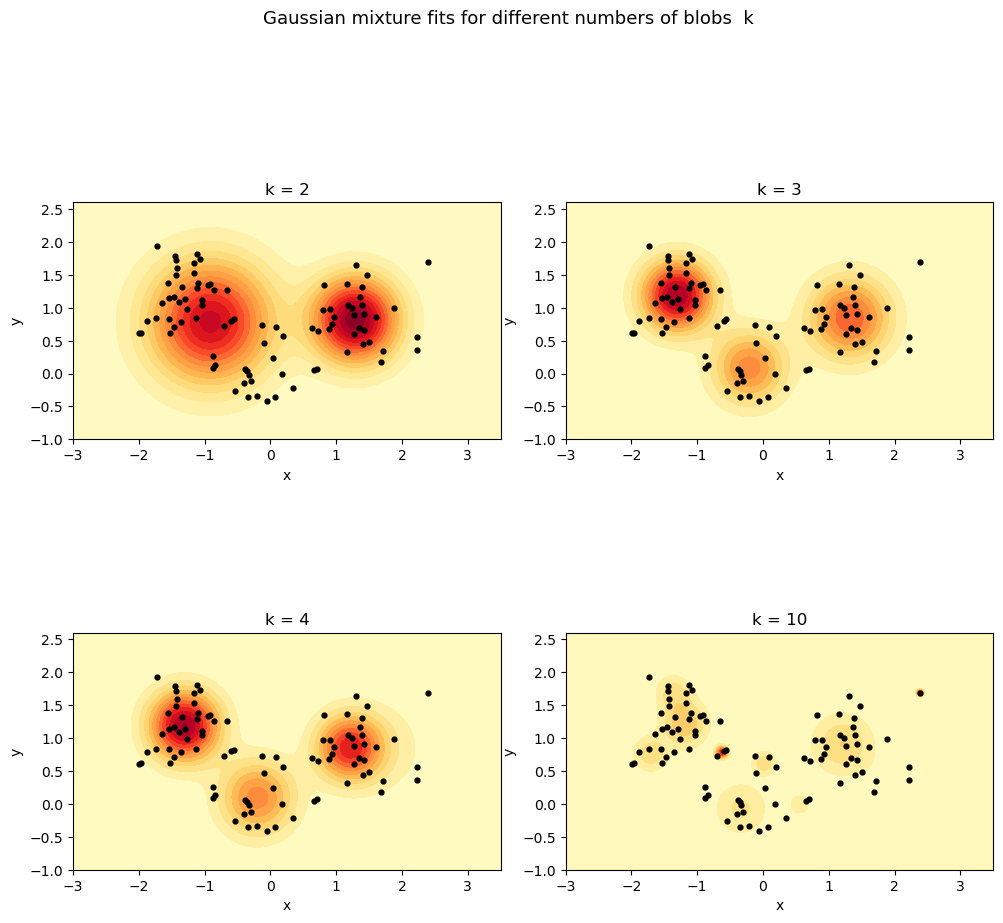

In [7]:
def fit_mixture(X, k, reg_covar=1e-3, seed=42):
    gm = GaussianMixture(n_components=k, covariance_type='spherical',
                         n_init=5, reg_covar=reg_covar, random_state=seed)
    gm.fit(X)
    return gm

def hoard_score_grid(gm, XX, YY):
    """Evaluate the fitted density on a meshgrid."""
    XY = np.column_stack([XX.ravel(), YY.ravel()])
    return np.exp(gm.score_samples(XY)).reshape(XX.shape)

ks  = [2, 3, 4, 10]
gms = {k: fit_mixture(X, k) for k in ks}

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, k in zip(axes.ravel(), ks):
    Z = hoard_score_grid(gms[k], XX, YY)
    ax.contourf(XX, YY, Z, levels=15, cmap='YlOrRd')
    ax.scatter(X[:, 0], X[:, 1], color='k', s=12, zorder=4)
    ax.set_title(f'k = {k}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')

plt.suptitle('Gaussian mixture fits for different numbers of blobs  k',
             y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

At $k = 2$ the three clusters are partially merged. At $k = 3$ the structure looks well captured. At $k = 10$ the density is spiky — placing concentrated blobs close to individual datapoints, memorising $D$ rather than describing the underlying pattern. We need a principled way to choose $k$.

---
## 5 · Choosing $k$: training score and cross-validation

> **Book link — §3.3–3.4.**  The **training log-product score** $\ell_k(\hat{\boldsymbol\theta}_k) = \sum_{\boldsymbol{x} \in D} \log f_k(\boldsymbol{x};\, \hat{\boldsymbol\theta}_k)$ measures how well the fitted density explains the data it was fitted to. Does a higher score mean a better $k$?

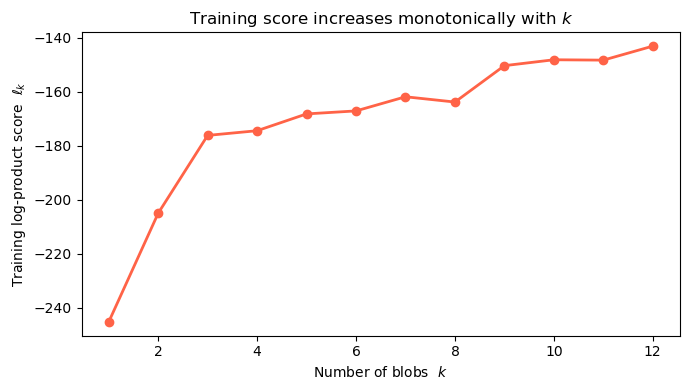

In [8]:
k_range = np.arange(1, 13)

# Training log-product score (fast)
train_scores = []
fitted_gms   = {}
for k in k_range:
    gm = fit_mixture(X, k)
    fitted_gms[k] = gm
    train_scores.append(gm.score_samples(X).sum())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_range, train_scores, 'o-', color='tomato', linewidth=2)
ax.set_xlabel('Number of blobs  $k$')
ax.set_ylabel('Training log-product score  $\\ell_k$')
ax.set_title('Training score increases monotonically with $k$')
plt.tight_layout()
plt.show()

The training score never decreases: a more flexible family (larger $k$) can always fit the observed data at least as well. Choosing $k$ to maximise the training score would always favour the largest available $k$ — which, at the extreme, places a separate blob on every datapoint and is useless for locating *new* hoards.

**Cross-validation** offers an escape. If we hold out one datapoint, fit the density to the remaining 89, and evaluate at the held-out point, we get a genuine test of how well the fitted density generalises. Repeating for every point and summing gives the **leave-one-out cross-validation score**:

$$\mathrm{LOOCV}(k) = \sum_{i=1}^{90} \log f_k\!\left(\boldsymbol{x}_i;\, \hat{\boldsymbol\theta}_{k,-i}\right),$$

where $\hat{\boldsymbol\theta}_{k,-i}$ is obtained by fitting to all points *except* $\boldsymbol{x}_i$.

In [9]:
# LOO-CV: fits 90 models per k — takes roughly 30–60 seconds in total
def loocv_score(X, k):
    n          = len(X)
    log_scores = np.zeros(n)
    for i in range(n):
        mask = np.ones(n, dtype=bool)
        mask[i] = False
        gm = fit_mixture(X[mask], k)
        log_scores[i] = gm.score_samples(X[[i]])[0]
    return log_scores.sum()

loocv_scores = [loocv_score(X, k) for k in k_range]
print('LOOCV done.')

LOOCV done.


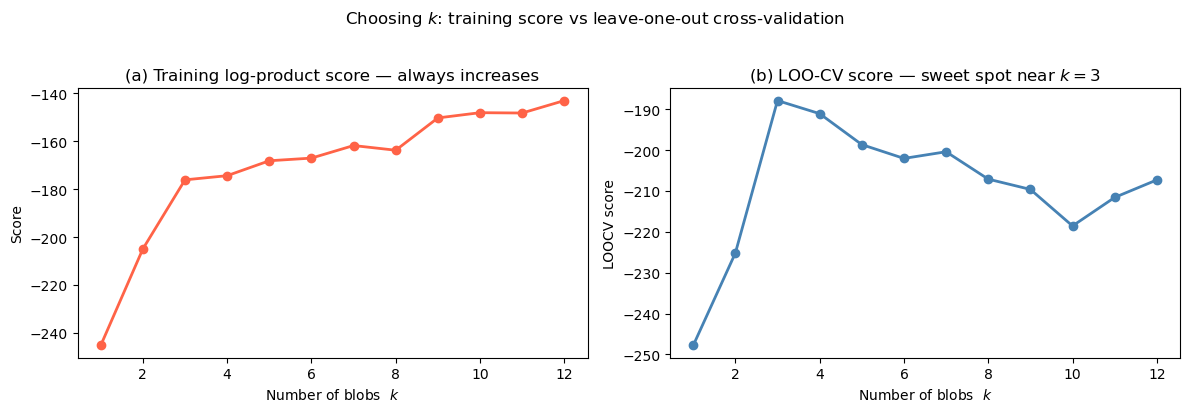

Best k by LOOCV: 3


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, train_scores, 'o-', color='tomato', linewidth=2)
axes[0].set_xlabel('Number of blobs  $k$')
axes[0].set_ylabel('Score')
axes[0].set_title('(a) Training log-product score — always increases')

axes[1].plot(k_range, loocv_scores, 'o-', color='steelblue', linewidth=2)
axes[1].set_xlabel('Number of blobs  $k$')
axes[1].set_ylabel('LOOCV score')
axes[1].set_title('(b) LOO-CV score — sweet spot near $k = 3$')

plt.suptitle('Choosing $k$: training score vs leave-one-out cross-validation', y=1.02)
plt.tight_layout()
plt.show()

best_k = int(k_range[np.argmax(loocv_scores)])
print(f'Best k by LOOCV: {best_k}')

The LOOCV score rises from $k = 1$ to $k = 3$ — the model gains useful structure — then falls: extra blobs start fitting noise rather than genuine clusters, and the density fails to anticipate where held-out hoards actually appear.

This is **overfitting** in an unsupervised context. The parallel with Chapter 2 is direct: increasing $k$ increases the *flexibility* of the function family, just as increasing polynomial degree did. Beyond a certain point — here $k = 3$ — extra flexibility is not helpful for anticipating hold-out data.

---
## Exercises

### Exercise 1 — Bin width selection by cross-validation

The choice of bin width in a histogram is analogous to the choice of $k$ in a mixture model: too narrow and the histogram is spiky (overfitting); too wide and it is flat (underfitting).

Take just the $x$-coordinates of the 90 treasure points.

**(a)** Plot histograms with bin widths $h \in \{0.2,\, 0.5,\, 1.0,\, 2.0\}$ on a single figure and comment on under- and overfitting.

**(b)** Implement LOO-CV for histogram density estimation: for each held-out point $x_i$, compute the histogram density at $x_i$ using the remaining 89 points, and sum the log values. Plot the LOO-CV score as a function of $h$ and identify a good bin width.

*Hint: to evaluate the histogram density at a point, find which bin it falls in and use $\hat{f}(x_i) = \text{count in that bin} / (89 \times h)$. A point in an empty bin contributes $-\infty$ to the sum; handle this by replacing with a large negative constant (and noting the choice).*

In [11]:
x_coords = X[:, 0]   # x-coordinates of the 90 treasure points

# (a) Your plots here

# (b) Your LOO-CV here


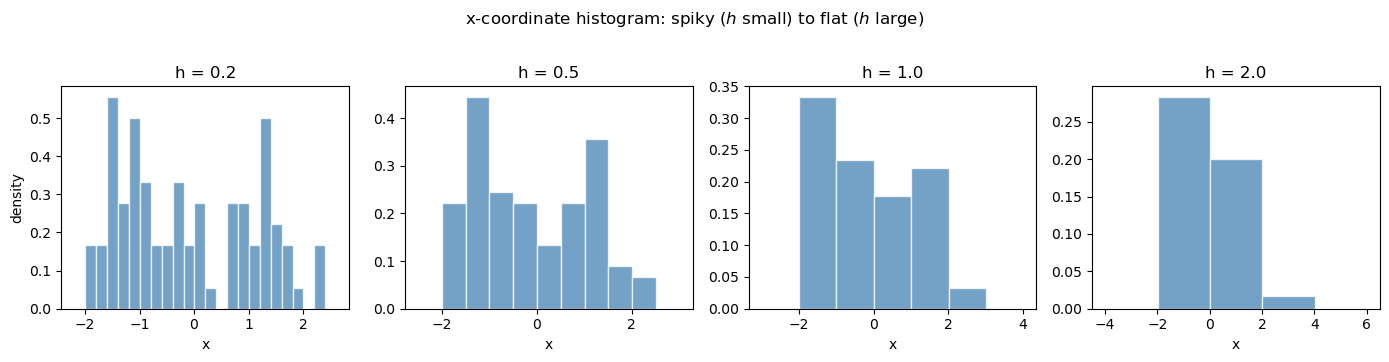

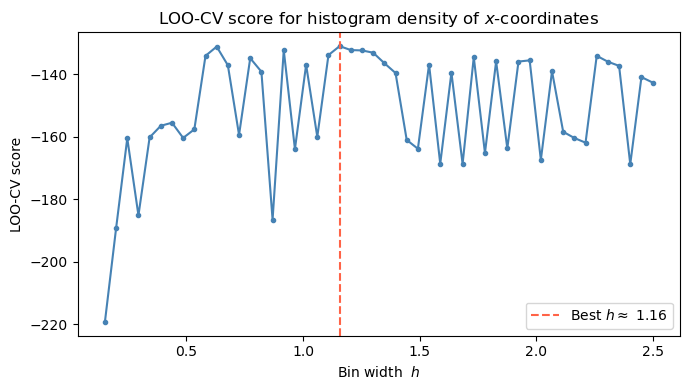

Best bin width: h ≈ 1.16


In [12]:
# Solution
x_coords = X[:, 0]

# (a) Four histograms
bws  = [0.2, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=False)
for ax, h in zip(axes, bws):
    bins = np.arange(x_coords.min() - h, x_coords.max() + 2 * h, h)
    ax.hist(x_coords, bins=bins, density=True,
            color='steelblue', alpha=0.75, edgecolor='white')
    ax.set_title(f'h = {h}')
    ax.set_xlabel('x')
axes[0].set_ylabel('density')
plt.suptitle('x-coordinate histogram: spiky ($h$ small) to flat ($h$ large)', y=1.02)
plt.tight_layout()
plt.show()
# Small h: spiky — the histogram memorises gaps between points (overfitting).
# Large h: flat — real cluster structure is washed out (underfitting).

# (b) LOO-CV
def loocv_histogram(x, h, empty_log=-30.0):
    n     = len(x)
    x_lo  = x.min() - h
    bins  = np.arange(x_lo, x.max() + 2 * h, h)
    total = 0.0
    for i in range(n):
        mask             = np.ones(n, dtype=bool)
        mask[i]          = False
        counts, edges    = np.histogram(x[mask], bins=bins)
        bin_idx          = np.searchsorted(edges, x[i], side='right') - 1
        bin_idx          = np.clip(bin_idx, 0, len(counts) - 1)
        c                = counts[bin_idx]
        total           += np.log(c / ((n - 1) * h)) if c > 0 else empty_log
    return total

h_grid    = np.linspace(0.15, 2.5, 50)
loocv_h   = [loocv_histogram(x_coords, h) for h in h_grid]
best_h    = h_grid[np.argmax(loocv_h)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(h_grid, loocv_h, 'o-', color='steelblue', markersize=3, linewidth=1.5)
ax.axvline(best_h, color='tomato', linestyle='--', label=f'Best $h \\approx$ {best_h:.2f}')
ax.set_xlabel('Bin width  $h$')
ax.set_ylabel('LOO-CV score')
ax.set_title('LOO-CV score for histogram density of $x$-coordinates')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best bin width: h ≈ {best_h:.2f}')
# The LOO-CV curve peaks at an intermediate h — too small and the histogram
# is too spiky to predict held-out points well; too large and it is too flat.

### Exercise 2 — The overfit heat map

The collapse problem discussed in §3.3 can be made visible. Refit the $k = 10$ mixture with a very small minimum blob width (`reg_covar=1e-6` instead of `1e-3`). Plot the resulting heat map alongside the $k = 3$ fit from §4.

What do you observe, and what would this density tell the Queen's diggers to do?

In [13]:
# Your answer here


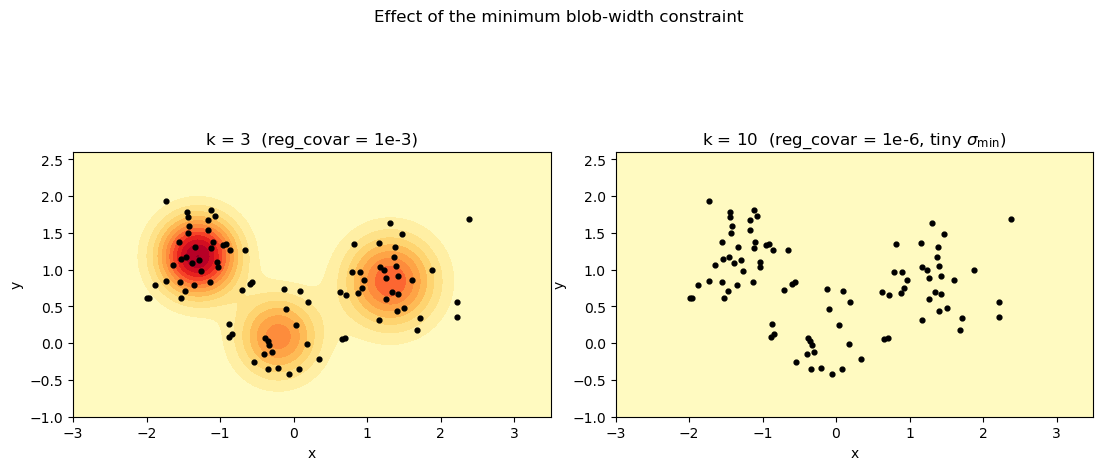

In [14]:
# Solution
gm_overfit = fit_mixture(X, k=10, reg_covar=1e-6)

Z_k3      = hoard_score_grid(fitted_gms[3], XX, YY)
Z_overfit = hoard_score_grid(gm_overfit,    XX, YY)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

titles = ['k = 3  (reg_covar = 1e-3)', 'k = 10  (reg_covar = 1e-6, tiny $\\sigma_{\\min}$)']
for ax, Z, title in zip(axes, [Z_k3, Z_overfit], titles):
    ax.contourf(XX, YY, Z, levels=15, cmap='YlOrRd')
    ax.scatter(X[:, 0], X[:, 1], color='k', s=12, zorder=4)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')

plt.suptitle('Effect of the minimum blob-width constraint', y=1.02)
plt.tight_layout()
plt.show()

# The overfit density places sharp spikes on individual datapoints.
# Diggers guided by this map would be directed to the 90 *known* hoard locations —
# exactly the wrong strategy.  The k=3 density spreads probability mass across the
# clusters, anticipating new hoards nearby rather than at already-known sites.

### Exercise 3 — Five-fold cross-validation

LOO-CV refits the model $n = 90$ times per value of $k$. For larger datasets this becomes expensive. A cheaper alternative is **$F$-fold CV**: split $D$ into $F = 5$ roughly equal folds, hold each fold out in turn as a validation set, fit on the remaining $F - 1$ folds, and sum the log-density values at the held-out points.

Implement 5-fold CV and plot the resulting score alongside the LOO-CV curve already computed. Does 5-fold CV agree with LOO-CV on the best number of blobs?

In [15]:
# Your answer here


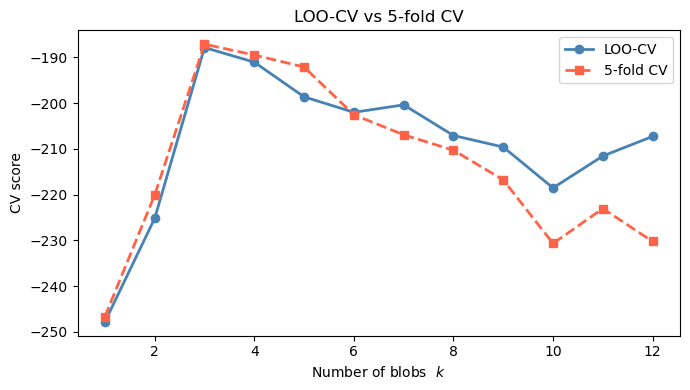

Best k  —  LOO-CV: 3,   5-fold CV: 3


In [16]:
# Solution
def fivefold_cv_score(X, k, n_folds=5, seed=7):
    n          = len(X)
    idx        = np.random.default_rng(seed).permutation(n)
    log_scores = np.zeros(n)
    for fold_idx in np.array_split(idx, n_folds):
        val_mask           = np.zeros(n, dtype=bool)
        val_mask[fold_idx] = True
        gm                 = fit_mixture(X[~val_mask], k)
        log_scores[fold_idx] = gm.score_samples(X[fold_idx])
    return log_scores.sum()

cv5_scores = [fivefold_cv_score(X, k) for k in k_range]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_range, loocv_scores, 'o-',  color='steelblue', linewidth=2, label='LOO-CV')
ax.plot(k_range, cv5_scores,   's--', color='tomato',    linewidth=2, label='5-fold CV')
ax.set_xlabel('Number of blobs  $k$')
ax.set_ylabel('CV score')
ax.set_title('LOO-CV vs 5-fold CV')
ax.legend()
plt.tight_layout()
plt.show()

best_k_loocv = int(k_range[np.argmax(loocv_scores)])
best_k_cv5   = int(k_range[np.argmax(cv5_scores)])
print(f'Best k  —  LOO-CV: {best_k_loocv},   5-fold CV: {best_k_cv5}')
# Both methods should favour k = 3 (or nearby).  The 5-fold curve is noisier
# because each validation fold contains only ~18 points rather than 1.